<a href="https://colab.research.google.com/github/SamManuJacob/6thSem-ML-Lab/blob/main/USN_Lab_6_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Imports & Setup

In [1]:
import math, csv, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 1. KNN From Scratch – Core Implementation

In [2]:
# ─── Euclidean distance ───────────────────────────────────────────────────
def euclidean_distance(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

# ─── KNN Classifier ───────────────────────────────────────────────────────
class KNNScratch:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = [list(x) for x in X_train]
        self.y_train = list(y_train)

    def predict(self, X_test):
        return [self._predict_one(list(x)) for x in X_test]

    def _predict_one(self, x):
        dists = sorted(
            [(euclidean_distance(x, xt), yt)
             for xt, yt in zip(self.X_train, self.y_train)],
            key=lambda d: d[0]
        )
        k_labels = [label for _, label in dists[:self.k]]
        return Counter(k_labels).most_common(1)[0][0]

    def score(self, X_test, y_test):
        preds = self.predict(X_test)
        return sum(p == a for p, a in zip(preds, y_test)) / len(y_test)

# ─── Standard Scaler (scratch) ────────────────────────────────────────────
def scratch_standard_scaler(X_train, X_test):
    X_train = [list(r) for r in X_train]
    X_test  = [list(r) for r in X_test]
    n_feats = len(X_train[0])
    means, stds = [], []
    for j in range(n_feats):
        col = [row[j] for row in X_train]
        m = sum(col) / len(col)
        s = math.sqrt(sum((v - m)**2 for v in col) / len(col))
        means.append(m); stds.append(s if s != 0 else 1)
    def scale(X):
        return [[(row[j] - means[j]) / stds[j] for j in range(n_feats)]
                for row in X]
    return scale(X_train), scale(X_test)

# ─── Confusion matrix (scratch) ───────────────────────────────────────────
def scratch_confusion_matrix(y_true, y_pred):
    labels = sorted(set(list(y_true) + list(y_pred)))
    idx    = {l: i for i, l in enumerate(labels)}
    n      = len(labels)
    cm     = [[0]*n for _ in range(n)]
    for t, p in zip(y_true, y_pred):
        cm[idx[t]][idx[p]] += 1
    return np.array(cm), labels

# ─── Classification report (scratch) ──────────────────────────────────────
def scratch_classification_report(y_true, y_pred):
    labels = sorted(set(list(y_true) + list(y_pred)))
    rows = []
    for label in labels:
        tp = sum(1 for t,p in zip(y_true,y_pred) if t==label and p==label)
        fp = sum(1 for t,p in zip(y_true,y_pred) if t!=label and p==label)
        fn = sum(1 for t,p in zip(y_true,y_pred) if t==label and p!=label)
        sup = tp + fn
        prec   = tp/(tp+fp) if tp+fp else 0
        recall = tp/(tp+fn) if tp+fn else 0
        f1     = 2*prec*recall/(prec+recall) if prec+recall else 0
        rows.append((str(label), prec, recall, f1, sup))
    acc = sum(t==p for t,p in zip(y_true,y_pred))/len(y_true)
    print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-"*57)
    for r in rows:
        print(f"{r[0]:<15} {r[1]:>10.2f} {r[2]:>10.2f} {r[3]:>10.2f} {r[4]:>10}")
    print(f"\nAccuracy: {acc:.4f}  ({int(acc*len(y_true))}/{len(y_true)})")
    return acc

# ─── Plot confusion matrix helper ─────────────────────────────────────────
def plot_cm(cm, labels, title="Confusion Matrix", ax=None):
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    if show:
        plt.tight_layout(); plt.show()

print("KNN Scratch helpers defined ✔")

KNN Scratch helpers defined ✔


---
## Part 1 – IRIS Dataset
### 1a. Load & Split Data (80/20)

In [9]:
iris = pd.read_csv("iris.csv")

feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris[feature_cols].values
y = iris['species'].values
labels_iris = sorted(iris['species'].unique())

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f"Train: {len(X_tr)}  |  Test: {len(X_te)}")
iris.head()

Train: 120  |  Test: 30


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 1b. Find Best K (Accuracy Rate & Error Rate)

K        Accuracy  Error Rate
------------------------------
1          1.0000      0.0000  ← BEST K
2          1.0000      0.0000
3          1.0000      0.0000
4          1.0000      0.0000
5          1.0000      0.0000
6          1.0000      0.0000
7          0.9667      0.0333
8          1.0000      0.0000
9          1.0000      0.0000
10         1.0000      0.0000
11         1.0000      0.0000
12         1.0000      0.0000
13         1.0000      0.0000
14         1.0000      0.0000
15         1.0000      0.0000
16         1.0000      0.0000
17         1.0000      0.0000
18         1.0000      0.0000
19         1.0000      0.0000
20         1.0000      0.0000


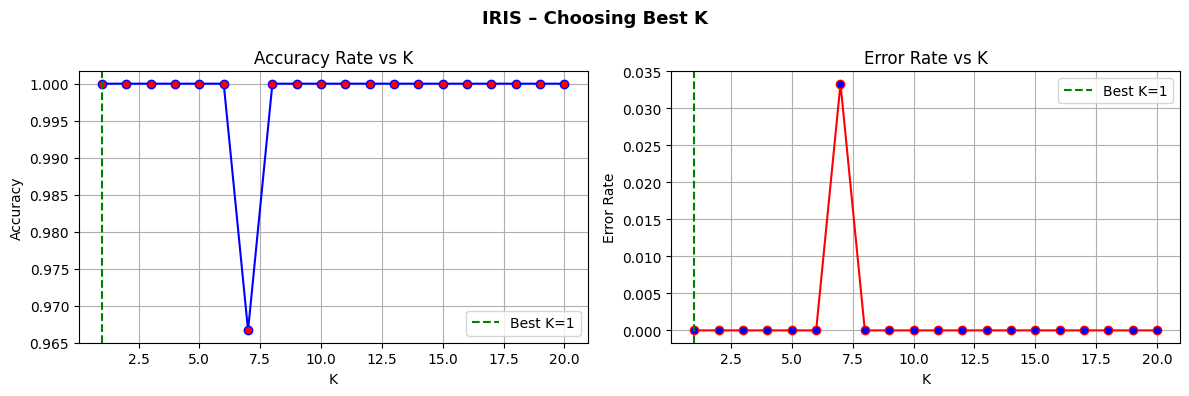


✅ Best K for IRIS = 1


In [10]:
k_range = range(1, 21)
acc_rates, err_rates = [], []

for k in k_range:
    knn = KNNScratch(k=k)
    knn.fit(X_tr.tolist(), y_tr.tolist())
    a = knn.score(X_te.tolist(), y_te.tolist())
    acc_rates.append(a); err_rates.append(1-a)

best_k_iris = k_range[acc_rates.index(max(acc_rates))]

# Table
print(f"{'K':<5}{'Accuracy':>12}{'Error Rate':>12}")
print("-"*30)
for k,a,e in zip(k_range,acc_rates,err_rates):
    flag = "  ← BEST K" if k==best_k_iris else ""
    print(f"{k:<5}{a:>12.4f}{e:>12.4f}{flag}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, acc_rates, 'bo-', markerfacecolor='red')
axes[0].axvline(best_k_iris, color='green', linestyle='--', label=f'Best K={best_k_iris}')
axes[0].set_title('Accuracy Rate vs K'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(k_range, err_rates, 'ro-', markerfacecolor='blue')
axes[1].axvline(best_k_iris, color='green', linestyle='--', label=f'Best K={best_k_iris}')
axes[1].set_title('Error Rate vs K'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Error Rate')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('IRIS – Choosing Best K', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"\n✅ Best K for IRIS = {best_k_iris}")

### 1c. KNN **WITHOUT** Library (From Scratch)

=== KNN WITHOUT Library | K=1 ===
Accuracy Score: 1.0000 (100.00%)

--- Classification Report ---
Class            Precision     Recall   F1-Score    Support
---------------------------------------------------------
setosa                1.00       1.00       1.00         10
versicolor            1.00       1.00       1.00          9
virginica             1.00       1.00       1.00         11

Accuracy: 1.0000  (30/30)

--- Confusion Matrix ---


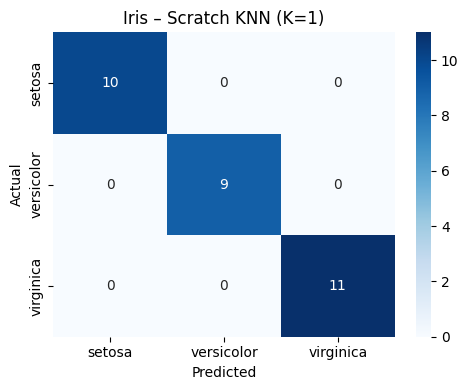

In [12]:
knn_iris_scratch = KNNScratch(k=best_k_iris)
knn_iris_scratch.fit(X_tr.tolist(), y_tr.tolist())
y_pred_scratch = knn_iris_scratch.predict(X_te.tolist())

acc = knn_iris_scratch.score(X_te.tolist(), y_te.tolist())
print(f"=== KNN WITHOUT Library | K={best_k_iris} ===")
print(f"Accuracy Score: {acc:.4f} ({acc*100:.2f}%)\n")

print("--- Classification Report ---")
scratch_classification_report(y_te.tolist(), y_pred_scratch)

cm_s, lbl_s = scratch_confusion_matrix(y_te.tolist(), y_pred_scratch)
lbl_s_names = lbl_s
print("\n--- Confusion Matrix ---")
plot_cm(cm_s, lbl_s_names, title=f"Iris – Scratch KNN (K={best_k_iris})")

### 1d. KNN **WITH** Library (sklearn)

=== KNN WITH sklearn | K=1 ===
Accuracy Score: 1.0000

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



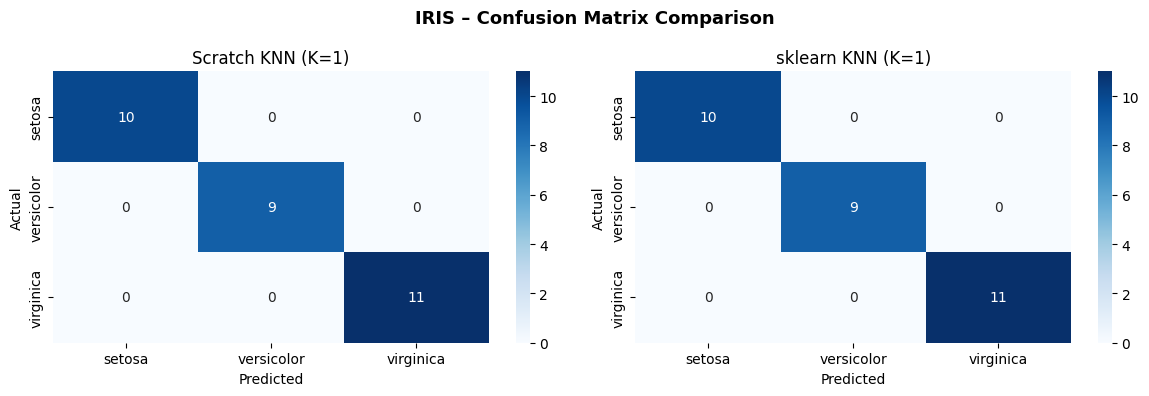

In [14]:
knn_iris_sk = KNeighborsClassifier(n_neighbors=best_k_iris)
knn_iris_sk.fit(X_tr, y_tr)
y_pred_sk = knn_iris_sk.predict(X_te)

print(f"=== KNN WITH sklearn | K={best_k_iris} ===")
print(f"Accuracy Score: {accuracy_score(y_te, y_pred_sk):.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_te, y_pred_sk, target_names=labels_iris))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_cm(cm_s, lbl_s_names, title=f"Scratch KNN (K={best_k_iris})", ax=axes[0])
cm_sk = confusion_matrix(y_te, y_pred_sk)
plot_cm(cm_sk, labels_iris, title=f"sklearn KNN (K={best_k_iris})", ax=axes[1])
plt.suptitle("IRIS – Confusion Matrix Comparison", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 2 – Diabetes Dataset
### 2a. Load Data

In [15]:
df_d = pd.read_csv("diabetes.csv")
print(df_d.shape)
df_d.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2b. Feature Scaling – Why & How?
> **Why?** KNN relies on Euclidean distance. Features with large value ranges
> (e.g., Glucose 0–200 vs BMI 0–70) dominate the distance calculation, causing
> bias. Scaling ensures all features contribute equally.
>
> **How?** StandardScaler → z = (x − mean) / std

/tmp/ipykernel_438/547666602.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X_tr_d, labels=feature_cols, vert=True)
/tmp/ipykernel_438/547666602.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_tr_d_scaled, labels=feature_cols, vert=True)


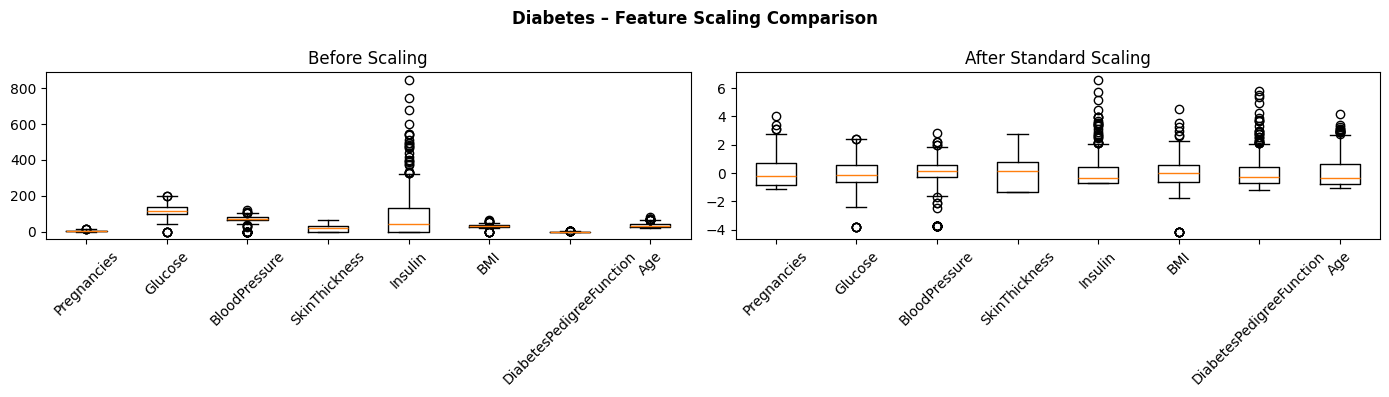

Train: 614  |  Test: 154


In [16]:
target_col  = 'Outcome' if 'Outcome' in df_d.columns else 'target'
feature_cols = [c for c in df_d.columns if c != target_col]

X_d = df_d[feature_cols].values
y_d = df_d[target_col].values

X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=SEED)

# Visualise before vs after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].boxplot(X_tr_d, labels=feature_cols, vert=True)
axes[0].set_title("Before Scaling"); axes[0].tick_params(axis='x', rotation=45)

scaler_d = StandardScaler()
X_tr_d_scaled = scaler_d.fit_transform(X_tr_d)
X_te_d_scaled = scaler_d.transform(X_te_d)

axes[1].boxplot(X_tr_d_scaled, labels=feature_cols, vert=True)
axes[1].set_title("After Standard Scaling"); axes[1].tick_params(axis='x', rotation=45)
plt.suptitle("Diabetes – Feature Scaling Comparison", fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Train: {len(X_tr_d)}  |  Test: {len(X_te_d)}")

### 2c. Find Best K

Best K for Diabetes = 20 (Accuracy = 0.7662)


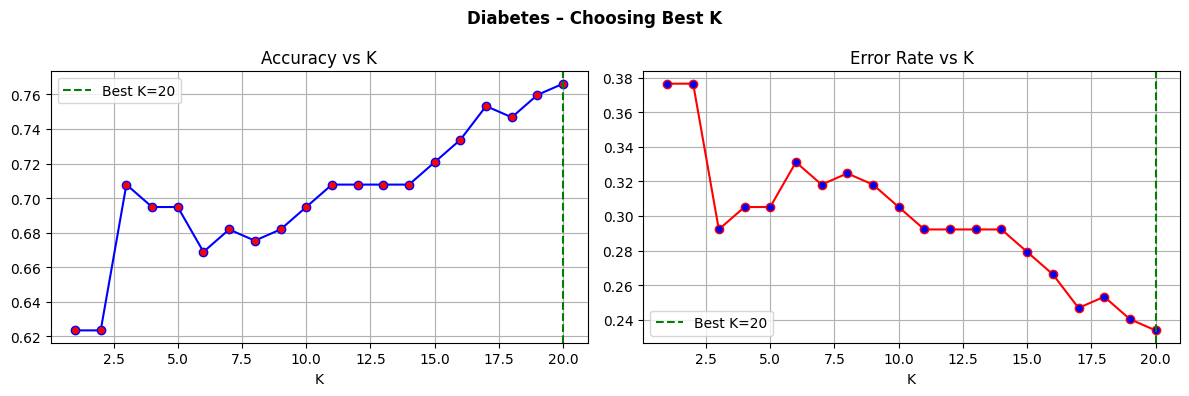

In [17]:
X_tr_d_sc_list, X_te_d_sc_list = scratch_standard_scaler(X_tr_d.tolist(), X_te_d.tolist())

k_range = range(1, 21)
acc_d, err_d = [], []
for k in k_range:
    knn = KNNScratch(k=k)
    knn.fit(X_tr_d_sc_list, y_tr_d.tolist())
    a = knn.score(X_te_d_sc_list, y_te_d.tolist())
    acc_d.append(a); err_d.append(1-a)

best_k_diab = k_range[acc_d.index(max(acc_d))]
print(f"Best K for Diabetes = {best_k_diab} (Accuracy = {max(acc_d):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, acc_d, 'bo-', markerfacecolor='red')
axes[0].axvline(best_k_diab, color='green', linestyle='--', label=f'Best K={best_k_diab}')
axes[0].set_title('Accuracy vs K'); axes[0].set_xlabel('K'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(k_range, err_d, 'ro-', markerfacecolor='blue')
axes[1].axvline(best_k_diab, color='green', linestyle='--', label=f'Best K={best_k_diab}')
axes[1].set_title('Error Rate vs K'); axes[1].set_xlabel('K'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Diabetes – Choosing Best K', fontweight='bold')
plt.tight_layout(); plt.show()

### 2d. KNN **WITHOUT** Library

=== KNN WITHOUT Library | K=20 ===
Accuracy Score: 0.7662 (76.62%)

--- Classification Report ---
Class            Precision     Recall   F1-Score    Support
---------------------------------------------------------
0                     0.78       0.88       0.83         99
1                     0.72       0.56       0.63         55

Accuracy: 0.7662  (118/154)


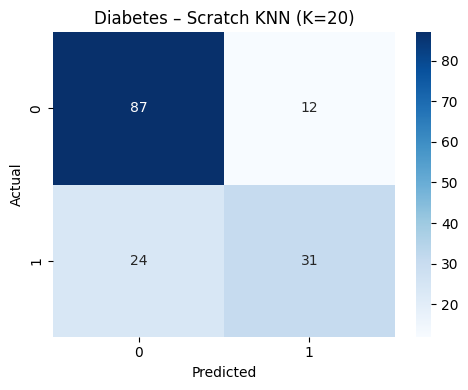

In [18]:
knn_diab_scratch = KNNScratch(k=best_k_diab)
knn_diab_scratch.fit(X_tr_d_sc_list, y_tr_d.tolist())
y_pred_d_s = knn_diab_scratch.predict(X_te_d_sc_list)

acc_ds = knn_diab_scratch.score(X_te_d_sc_list, y_te_d.tolist())
print(f"=== KNN WITHOUT Library | K={best_k_diab} ===")
print(f"Accuracy Score: {acc_ds:.4f} ({acc_ds*100:.2f}%)\n")

print("--- Classification Report ---")
scratch_classification_report(y_te_d.tolist(), y_pred_d_s)

cm_ds, lbl_ds = scratch_confusion_matrix(y_te_d.tolist(), y_pred_d_s)
plot_cm(cm_ds, [str(l) for l in lbl_ds], title=f"Diabetes – Scratch KNN (K={best_k_diab})")

### 2e. KNN **WITH** Library (sklearn)

=== KNN WITH sklearn | K=20 ===
Accuracy Score: 0.7597

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.91      0.83        99
           1       0.75      0.49      0.59        55

    accuracy                           0.76       154
   macro avg       0.76      0.70      0.71       154
weighted avg       0.76      0.76      0.75       154



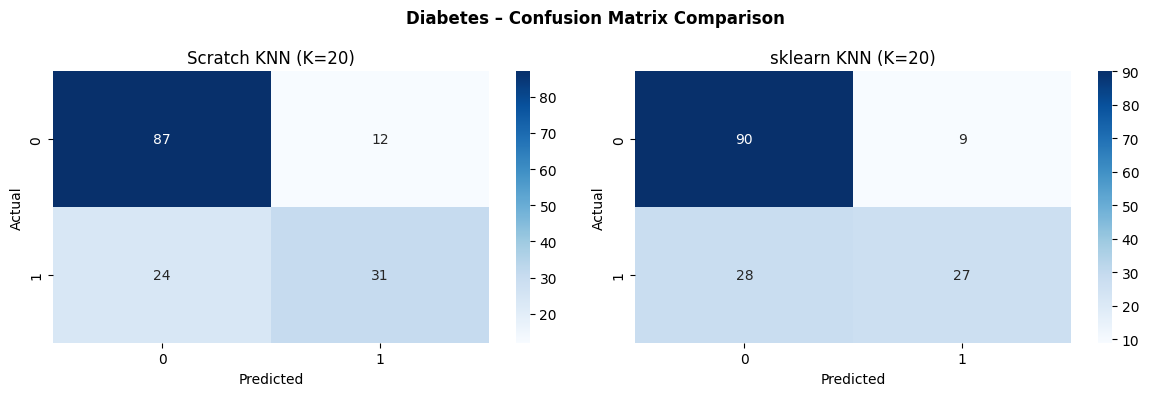

In [19]:
knn_diab_sk = KNeighborsClassifier(n_neighbors=best_k_diab)
knn_diab_sk.fit(X_tr_d_scaled, y_tr_d)
y_pred_d_sk = knn_diab_sk.predict(X_te_d_scaled)

print(f"=== KNN WITH sklearn | K={best_k_diab} ===")
print(f"Accuracy Score: {accuracy_score(y_te_d, y_pred_d_sk):.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_te_d, y_pred_d_sk))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_cm(cm_ds, [str(l) for l in lbl_ds], title=f"Scratch KNN (K={best_k_diab})", ax=axes[0])
plot_cm(confusion_matrix(y_te_d, y_pred_d_sk), ['0','1'], title=f"sklearn KNN (K={best_k_diab})", ax=axes[1])
plt.suptitle("Diabetes – Confusion Matrix Comparison", fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 3 – Heart Dataset
### 3a. Load Data

In [20]:
df_h = pd.read_csv("heart.csv")
print(df_h.shape)
df_h.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 3b. Find Best K

K        Accuracy  Error Rate
------------------------------
1          0.8525      0.1475
2          0.8197      0.1803
3          0.8525      0.1475
4          0.8525      0.1475
5          0.9016      0.0984
6          0.9016      0.0984
7          0.9180      0.0820  ← BEST
8          0.8689      0.1311
9          0.9016      0.0984
10         0.8852      0.1148
11         0.8852      0.1148
12         0.8689      0.1311
13         0.8852      0.1148
14         0.8689      0.1311
15         0.8689      0.1311
16         0.8852      0.1148
17         0.8852      0.1148
18         0.9016      0.0984
19         0.8852      0.1148
20         0.9016      0.0984


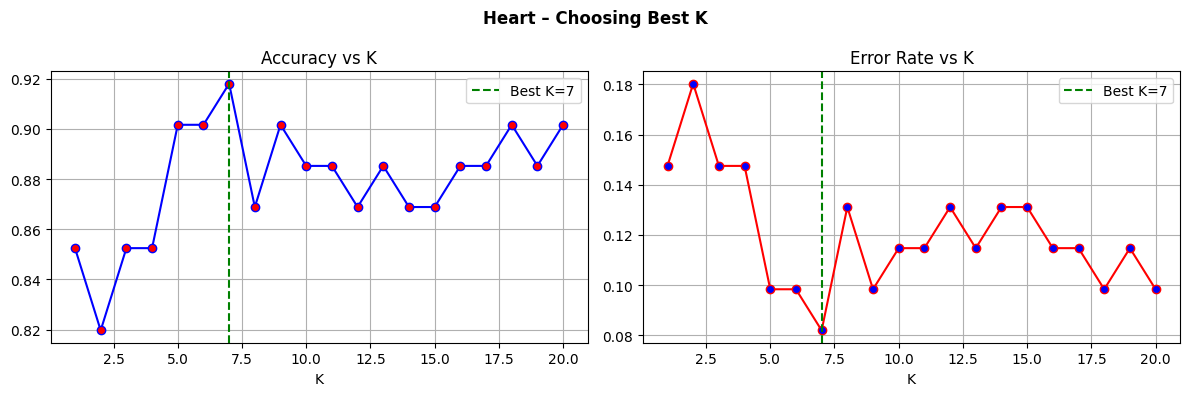


✅ Best K for Heart = 7


In [21]:
feat_cols_h  = [c for c in df_h.columns if c.lower() != 'target']
X_h = df_h[feat_cols_h].values
y_h = df_h['target'].values

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=SEED)

# Scale
scaler_h = StandardScaler()
X_tr_h_scaled = scaler_h.fit_transform(X_tr_h)
X_te_h_scaled = scaler_h.transform(X_te_h)
X_tr_h_sc_list, X_te_h_sc_list = scratch_standard_scaler(X_tr_h.tolist(), X_te_h.tolist())

k_range = range(1, 21)
acc_h, err_h = [], []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_h_scaled, y_tr_h)
    a = knn.score(X_te_h_scaled, y_te_h)
    acc_h.append(a); err_h.append(1-a)

best_k_heart = k_range[acc_h.index(max(acc_h))]
print(f"{'K':<5}{'Accuracy':>12}{'Error Rate':>12}")
print("-"*30)
for k,a,e in zip(k_range,acc_h,err_h):
    flag = "  ← BEST" if k==best_k_heart else ""
    print(f"{k:<5}{a:>12.4f}{e:>12.4f}{flag}")

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(k_range, acc_h, 'bo-', markerfacecolor='red')
axes[0].axvline(best_k_heart, color='green', linestyle='--', label=f'Best K={best_k_heart}')
axes[0].set_title('Accuracy vs K'); axes[0].set_xlabel('K'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(k_range, err_h, 'ro-', markerfacecolor='blue')
axes[1].axvline(best_k_heart, color='green', linestyle='--', label=f'Best K={best_k_heart}')
axes[1].set_title('Error Rate vs K'); axes[1].set_xlabel('K'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Heart – Choosing Best K', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"\n✅ Best K for Heart = {best_k_heart}")

### 3c. KNN **WITHOUT** Library

=== KNN WITHOUT Library | K=7 ===
Accuracy Score: 0.9180 (91.80%)

--- Classification Report ---
Class            Precision     Recall   F1-Score    Support
---------------------------------------------------------
0                     0.90       0.93       0.92         29
1                     0.94       0.91       0.92         32

Accuracy: 0.9180  (56/61)


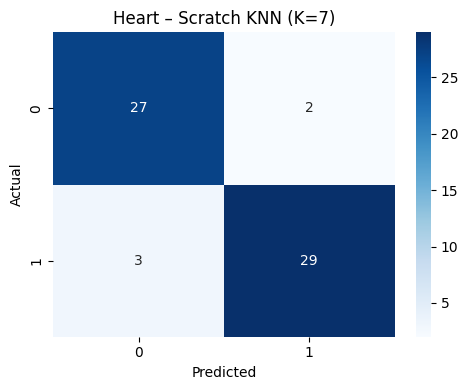

In [22]:
knn_h_scratch = KNNScratch(k=best_k_heart)
knn_h_scratch.fit(X_tr_h_sc_list, y_tr_h.tolist())
y_pred_h_s = knn_h_scratch.predict(X_te_h_sc_list)

acc_hs = knn_h_scratch.score(X_te_h_sc_list, y_te_h.tolist())
print(f"=== KNN WITHOUT Library | K={best_k_heart} ===")
print(f"Accuracy Score: {acc_hs:.4f} ({acc_hs*100:.2f}%)\n")

print("--- Classification Report ---")
scratch_classification_report(y_te_h.tolist(), y_pred_h_s)

cm_hs, lbl_hs = scratch_confusion_matrix(y_te_h.tolist(), y_pred_h_s)
plot_cm(cm_hs, [str(l) for l in lbl_hs], title=f"Heart – Scratch KNN (K={best_k_heart})")

### 3d. KNN **WITH** Library (sklearn) + Plots

=== KNN WITH sklearn | K=7 ===
Accuracy Score: 0.9180

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



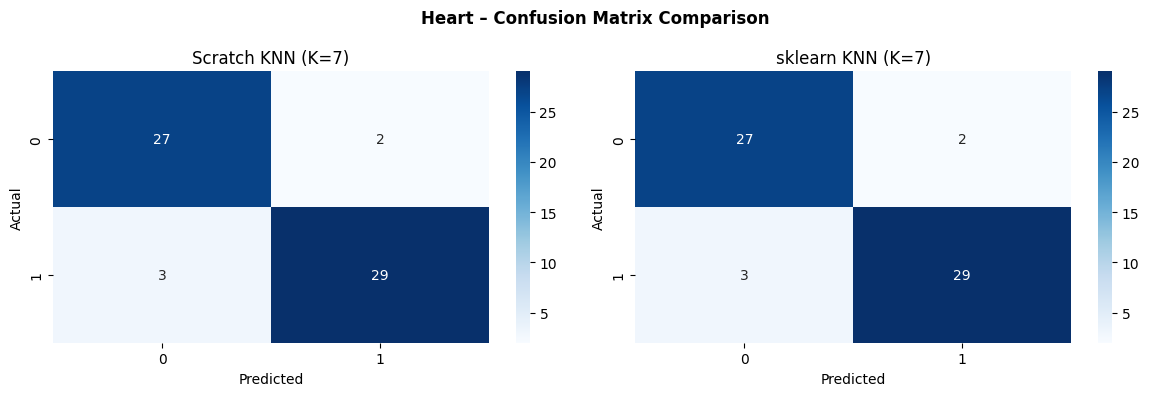

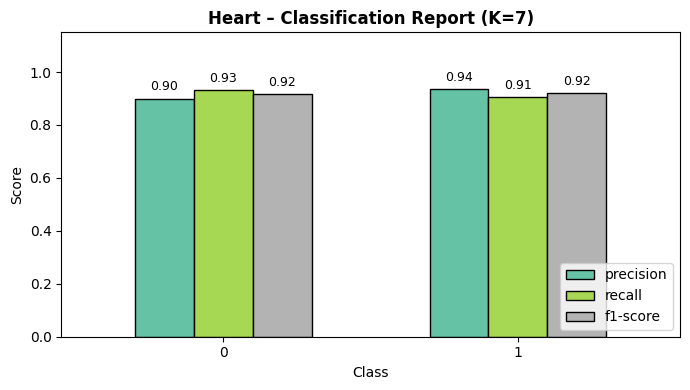

In [23]:
knn_h_sk = KNeighborsClassifier(n_neighbors=best_k_heart)
knn_h_sk.fit(X_tr_h_scaled, y_tr_h)
y_pred_h_sk = knn_h_sk.predict(X_te_h_scaled)

print(f"=== KNN WITH sklearn | K={best_k_heart} ===")
print(f"Accuracy Score: {accuracy_score(y_te_h, y_pred_h_sk):.4f}\n")
report = classification_report(y_te_h, y_pred_h_sk, output_dict=True)
print(classification_report(y_te_h, y_pred_h_sk))

# ── Plot Confusion Matrix ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_cm(cm_hs, [str(l) for l in lbl_hs], title=f"Scratch KNN (K={best_k_heart})", ax=axes[0])
plot_cm(confusion_matrix(y_te_h, y_pred_h_sk), ['0','1'], title=f"sklearn KNN (K={best_k_heart})", ax=axes[1])
plt.suptitle("Heart – Confusion Matrix Comparison", fontweight='bold')
plt.tight_layout(); plt.show()

# ── Plot Classification Report ────────────────────────────────────────────
report_df = pd.DataFrame(report).T.drop(['accuracy','macro avg','weighted avg'], errors='ignore')
report_df = report_df[['precision','recall','f1-score']].astype(float)

fig, ax = plt.subplots(figsize=(7, 4))
report_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.6)
ax.set_title(f'Heart – Classification Report (K={best_k_heart})', fontsize=12, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Score')
ax.set_ylim(0, 1.15); ax.legend(loc='lower right')
ax.set_xticklabels(report_df.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()+0.02),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

---
## 📓 Observation Book – Q2

### IRIS: How to choose K?
Use **Error Rate vs K** plot:
1. Try K = 1 to 20 (a common heuristic is K ≈ √n)
2. For each K, calculate **Accuracy Rate** = correct predictions / total
3. **Error Rate** = 1 − Accuracy Rate
4. Choose K at the **lowest error rate / highest accuracy**
5. Prefer **odd K** for binary classification to avoid ties

### Diabetes: Purpose of Feature Scaling
KNN computes Euclidean distance between points.  
Without scaling, features with **large numeric ranges** (e.g., Glucose 0–200)
dominate over those with small ranges (e.g., BMI 0–70), introducing bias.

**Standard Scaling:** z = (x − μ) / σ
- μ = mean of feature, σ = standard deviation
- Transforms each feature to mean=0, std=1
- Ensures all features contribute **equally** to the distance calculation
- **Always fit the scaler on training data only**, then transform test data